<a href="https://colab.research.google.com/github/guillevchar/EntregasCursoDeepLearning2026/blob/main/PRACTICA_04_GuillermoVicenteCharco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Guillermo Vicente Charco guivicen@ucm.es

<font color="darkorange" size="10"><b>04. Clasificación con MLP</b></font>

Miguel A. Castellanos

En esta práctica vamos a hacer clasificaciones binarias y múltiples

Son similares a las hechas con playground pero ahora crearemos y controlaremos nosotros los datos.

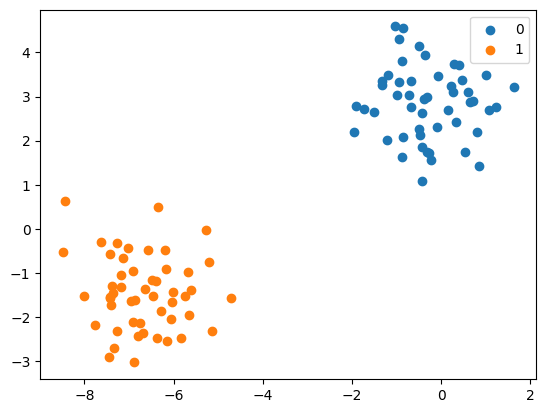

In [ ]:
# Vamos a empezar con 2 pelotas

from sklearn.datasets import make_blobs
from matplotlib import pyplot as plt

X, y = make_blobs(centers=2, cluster_std=0.8)

plt.scatter(X[y == 0, 0], X[y == 0, 1], label="0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="1")
plt.legend()

In [ ]:
# Vamos a instalar torcheval, es parte de torch y va a facilitar la evaluacion del modelo

!pip install torcheval

In [ ]:
# Preparamos los datos como antes, pero y no hay que normalizarla
import torch
from torch.utils.data import TensorDataset, DataLoader

# Normalizamos solo X

x_mean, x_std = X.mean(), X.std()
X_norm = (X - x_mean) / x_std

tensor_X = torch.Tensor(X_norm)
tensor_y = torch.Tensor(y)

my_dataset = TensorDataset(tensor_X,tensor_y) # create your datset
my_dataloader = DataLoader(my_dataset) # create your dataloader

In [ ]:
# definimos mi red igual que antes
# Es una red con 3 capas (50,25,1), todo relu menos la ultima capa que hace
# la clasificación binaria con una sigmoide

class MLP(torch.nn.Module):
    def __init__(self, num_features):
        super().__init__()

        self.all_layers = torch.nn.Sequential(

            # 1st hidden layer
            torch.nn.Linear(num_features, 50),
            torch.nn.ReLU(),

            # 2nd hidden layer
            torch.nn.Linear(50, 25),
            torch.nn.ReLU(),

            # output layer
            torch.nn.Linear(25, 1),
            # torch.nn.Sigmoid() # ver comentario 1

        )

    def forward(self, x):
        output = self.all_layers(x)
        # return output
        return output.flatten() # ver comentario 2

## Comentario 1

tenemos dos opciones, o definimos en la última capa la función sigmoid y usamos como función de costo BCELoss

```python
torch.nn.Sigmoid()
loss_fn = torch.nn.BCELoss()
```

O no definimmos sigmoid y usamos BCEWithLogitsLoss

```python
# torch.nn.Sigmoid()
loss_fn = torch.nn.BCEWithLogitsLoss()
```


Esta segunda opción funciona mucho mejor pero hay que tener en cuenta que va a devolver valores que no están entre [0,1] sino [-ing,+inf]


## Comentario 2
Ojo con las dimnsiones de entrada, salida y las internas
Por ejemplo en este codigo la red devuelve una lista (10,1) (una matriz) y los rasgos son (10,) (un vector)

```python
def forward(self, x):
  output = self.all_layers(x)
  return output
```

Siempre hay funciones que necesitan una cosa pero tú les pasas otra y hay que ajustarlas, en este caso hemos optado por "aplanar" la salida de la red para que coincida con el cálculo del accurary

```python
def forward(self, x):
  output = self.all_layers(x)
  return output.flatten()
```


In [ ]:
from torcheval.metrics import BinaryAccuracy, BinaryConfusionMatrix

# definimos hiper-parámetros

torch.manual_seed(1)

model = MLP(num_features=2) # instanciamos el modelo

# loss_fn = torch.nn.BCELoss() # Ojo, ahora es BCE, necesita sigmoid
loss_fn = torch.nn.BCEWithLogitsLoss() # Ojo, ahora es BCELog, no necesita sigmoid

optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # usamos Adam

acc = BinaryAccuracy() # calculamos la precisión (accurary)
m_confusion = BinaryConfusionMatrix(threshold=0.5)


In [ ]:
num_epochs = 10

# vamos a guardar el lost pero tambien el accuracy
loss_list, acc_list = [], []

for epoch in range(num_epochs):

    model.train()
    for batch_idx, (features, targets) in enumerate(my_dataloader):

        # forward
        output = model(features)
        loss = loss_fn(output, targets)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Esto es algo especifico para la evaluacion, en cada epoca actualizamos:
        acc.update(output, targets)      # el accuracy

        # añadimos los nuevos valores a la lista
        loss_list.append(loss.item())
        acc_list.append(acc.compute().item())

        if not batch_idx % 100:
            ### Imprimimos info
            print(
                f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
                f" | Batch {batch_idx:03d}/{len(my_dataloader):03d}"
                f" | Train Loss: {loss:.2f}"
                f" | Accuracy: {acc.compute():.2f}"
            )


Epoch: 001/010 | Batch 000/100 | Train Loss: 0.57 | Accuracy: 0.00
Epoch: 002/010 | Batch 000/100 | Train Loss: 0.22 | Accuracy: 0.91
Epoch: 003/010 | Batch 000/100 | Train Loss: 0.07 | Accuracy: 0.96
Epoch: 004/010 | Batch 000/100 | Train Loss: 0.04 | Accuracy: 0.97
Epoch: 005/010 | Batch 000/100 | Train Loss: 0.02 | Accuracy: 0.98
Epoch: 006/010 | Batch 000/100 | Train Loss: 0.01 | Accuracy: 0.98
Epoch: 007/010 | Batch 000/100 | Train Loss: 0.01 | Accuracy: 0.99
Epoch: 008/010 | Batch 000/100 | Train Loss: 0.01 | Accuracy: 0.99
Epoch: 009/010 | Batch 000/100 | Train Loss: 0.01 | Accuracy: 0.99
Epoch: 010/010 | Batch 000/100 | Train Loss: 0.00 | Accuracy: 0.99


In [ ]:
# Vemos que predicciones hace nuestro modelo para nuestro X

model.eval()
yp = model(tensor_X)
yp

tensor([ 5.5272, -6.6816,  8.5374, -6.2883, -8.0794,  8.3254, -6.6604,  7.0776,
        -6.1232,  6.4926, -6.0270, -7.6599,  8.1456, -5.6748, -5.5065,  8.1007,
         9.5711, -7.8086, -5.5112,  8.2412,  7.7254,  8.1796,  7.7436, -7.8910,
         6.3512, -5.6074,  8.0278,  8.2107, -8.0267, -6.3644,  9.2175, -5.9810,
         8.6498, -7.7604,  8.6430, -5.9915,  7.4765,  8.1667, -7.0594, -8.5206,
         6.6075,  9.2619,  8.6480,  7.1642,  8.9847, -7.5993,  8.5719, -4.6852,
        -7.7546, -7.1415, -7.0913, -5.8208, -6.8634,  7.9145,  7.5983, -6.5941,
         7.1525,  7.0856,  6.3845, -6.7010,  8.6601,  7.4135,  7.4998,  8.4244,
         7.4242, -7.0506, -8.2989, -6.6707,  6.7948,  6.9496,  6.8263, -7.9164,
        -7.1994, -7.3001,  8.0473, -6.6489,  7.5150, -7.6593, -7.6025, -7.5149,
        -6.6420,  8.0458,  9.1556, -6.0977, -6.1009, -6.8918, -7.7427,  7.2760,
        -6.9685, -7.8338, -6.8186,  8.8355, -6.6329,  4.9111,  8.4184,  5.3515,
         7.9274, -7.8598, -7.5812,  8.53

In [ ]:
# Calculamos una matriz de confusion

k = BinaryConfusionMatrix(threshold=0.)
k.update(yp, tensor_y.long())
print(k.compute())

tensor([[50.,  0.],
        [ 0., 50.]])


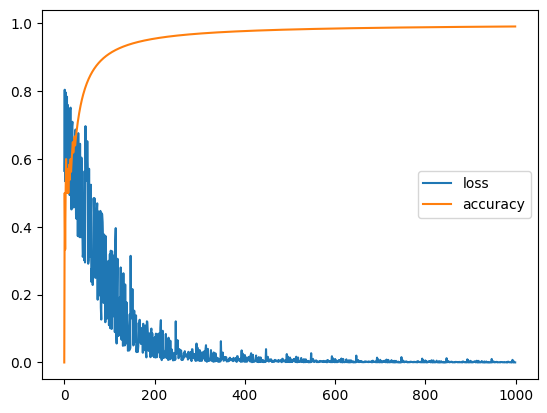

In [ ]:
# Ploteamos

plt.plot(loss_list)
plt.plot(acc_list)
plt.legend(['loss', 'accuracy'])
plt.show()

---
# Ejercicios

Crea un notebook de colab con las soluciones a los ejercicios, hazlo público y sube el enlace al campus virtual


### 01. Ejercicio 1

Usando el generador de pelotas make_blobs crea unos datos con 4 categorías y calcula un MLP para hacer la clasificación.

Ahora tendrás que modificar como ploteas

Y también la última función de activación de la red será una SoftMax

Al igual que con BCE, se prefiere la opción de hacer implicita esas funciones de activación y que sea la función que calcula la función de coste la que las incluya, es decir:



```python

# no se pone la softmax porque va incluida en el optimizador
# torch.nn.Softmax(dim=4)

...

# ya incluye automaticamente las softmax al definir fn_loss
loss_fn = torch.nn.CrossEntropyLoss()  
```



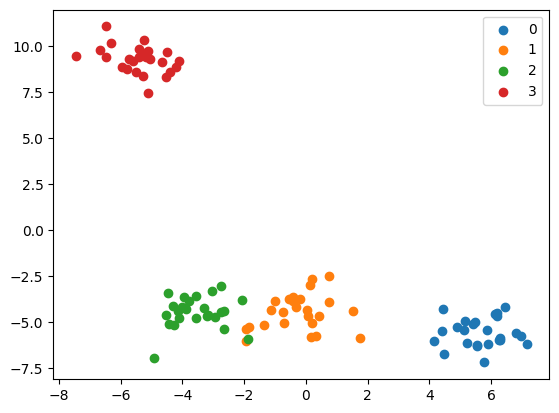

In [ ]:
from sklearn.datasets import make_blobs
from matplotlib import pyplot as plt

X, y = make_blobs(centers=4, cluster_std=0.8)

plt.scatter(X[y == 0, 0], X[y == 0, 1], label="0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="1")
plt.scatter(X[y == 2, 0], X[y == 2, 1], label="2")
plt.scatter(X[y == 3, 0], X[y == 3, 1], label="3")
plt.legend()
plt.show()

pasa lo mismo, no se pone la capa de softmax, va implicita al definir la funcion criterion = nn.CrossEntropyLoss()  # Combina softmax y NLLLoss



ahora la matriz de confusion es MulticlassConfusionMatrix(4)

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

x_mean, x_std = X.mean(), X.std()
X_norm = (X - x_mean) / x_std

tensor_X = torch.tensor(X_norm, dtype = torch.float32)
tensor_y = torch.tensor(y, dtype = torch.long)

my_dataset = TensorDataset(tensor_X,tensor_y)
my_dataloader = DataLoader(my_dataset)

In [ ]:
class MLP_1(torch.nn.Module):
    def __init__(self, num_features):
        super().__init__()

        self.all_layers = torch.nn.Sequential(

            # 1st hidden layer
            torch.nn.Linear(num_features, 10),
            torch.nn.ReLU(),

            # 2nd hidden layer
            torch.nn.Linear(10, 10),
            torch.nn.ReLU(),

            # output layer
            torch.nn.Linear(10, 4)

        )

    def forward(self, x):
        output = self.all_layers(x)
        return output


In [ ]:
from torcheval.metrics import MulticlassAccuracy, MulticlassConfusionMatrix

torch.manual_seed(1)

model = MLP_1(num_features=2)

loss_fn = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

acc = MulticlassAccuracy(num_classes = 4)
m_confusion = MulticlassConfusionMatrix(num_classes = 4)

In [ ]:
num_epochs = 50

# vamos a guardar el lost pero tambien el accuracy
loss_list, acc_list = [], []

for epoch in range(num_epochs):

    model.train()
    for batch_idx, (features, targets) in enumerate(my_dataloader):

        # forward
        output = model(features)
        loss = loss_fn(output, targets)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Esto es algo especifico para la evaluacion, en cada epoca actualizamos:
        acc.update(output, targets)      # el accuracy

        # añadimos los nuevos valores a la lista
        loss_list.append(loss.item())
        acc_list.append(acc.compute().item())

        if not batch_idx % 100:
            ### Imprimimos info
            print(
                f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
                f" | Batch {batch_idx:03d}/{len(my_dataloader):03d}"
                f" | Train Loss: {loss:.2f}"
                f" | Accuracy: {acc.compute():.2f}"
            )


Epoch: 001/050 | Batch 000/100 | Train Loss: 1.61 | Accuracy: 0.00
Epoch: 002/050 | Batch 000/100 | Train Loss: 1.57 | Accuracy: 0.25
Epoch: 003/050 | Batch 000/100 | Train Loss: 1.53 | Accuracy: 0.30
Epoch: 004/050 | Batch 000/100 | Train Loss: 1.48 | Accuracy: 0.37
Epoch: 005/050 | Batch 000/100 | Train Loss: 1.42 | Accuracy: 0.40
Epoch: 006/050 | Batch 000/100 | Train Loss: 1.31 | Accuracy: 0.43
Epoch: 007/050 | Batch 000/100 | Train Loss: 1.16 | Accuracy: 0.48
Epoch: 008/050 | Batch 000/100 | Train Loss: 0.99 | Accuracy: 0.53
Epoch: 009/050 | Batch 000/100 | Train Loss: 0.83 | Accuracy: 0.58
Epoch: 010/050 | Batch 000/100 | Train Loss: 0.66 | Accuracy: 0.62
Epoch: 011/050 | Batch 000/100 | Train Loss: 0.51 | Accuracy: 0.65
Epoch: 012/050 | Batch 000/100 | Train Loss: 0.39 | Accuracy: 0.68
Epoch: 013/050 | Batch 000/100 | Train Loss: 0.30 | Accuracy: 0.70
Epoch: 014/050 | Batch 000/100 | Train Loss: 0.24 | Accuracy: 0.72
Epoch: 015/050 | Batch 000/100 | Train Loss: 0.19 | Accuracy: 

In [ ]:

model.eval()
yp = model(tensor_X)
yp

tensor([[-1.0681e+01,  7.6497e-02,  4.8256e+00, -2.3995e+00],
        [ 8.4665e+00,  1.1242e+00, -2.0694e+01, -1.6493e+01],
        [-1.6183e-01,  2.2802e+00, -9.5722e+00, -1.0942e+01],
        [-1.3238e+01, -7.7391e-01,  5.8027e+00, -1.7936e+00],
        [-3.5093e+00,  2.4883e+00, -4.9922e+00, -8.3467e+00],
        [-9.8793e+00,  8.4714e-01,  3.0976e+00, -3.7207e+00],
        [-4.6297e+00,  2.2983e+00, -3.0558e+00, -6.8753e+00],
        [-1.1229e+01, -6.0137e-02,  5.2513e+00, -2.2714e+00],
        [ 8.0825e+00,  1.2354e+00, -2.0228e+01, -1.6313e+01],
        [-3.2190e+00,  2.5695e+00, -5.6151e+00, -8.8706e+00],
        [-8.9521e+00, -9.1772e+00, -2.3579e+00,  7.7187e+00],
        [-9.0897e+00, -9.2739e+00, -2.3508e+00,  7.7955e+00],
        [ 7.2989e+00,  1.2099e+00, -1.8756e+01, -1.5254e+01],
        [-8.3956e+00, -8.4116e+00, -2.1296e+00,  7.0242e+00],
        [ 8.5669e+00,  1.2667e+00, -2.1174e+01, -1.7012e+01],
        [-9.9286e+00, -8.8382e+00, -1.6046e+00,  7.2115e+00],
        

In [ ]:
# Calculamos una matriz de confusion

k = MulticlassConfusionMatrix(num_classes = 4)
k.update(yp, tensor_y.long())
print(k.compute())

tensor([[25.,  0.,  0.,  0.],
        [ 0., 25.,  0.,  0.],
        [ 0.,  1., 24.,  0.],
        [ 0.,  0.,  0., 25.]])


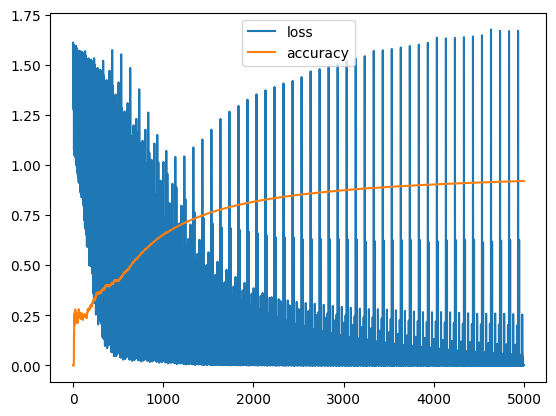

In [ ]:
# Ploteamos

plt.plot(loss_list)
plt.plot(acc_list)
plt.legend(['loss', 'accuracy'])
plt.show()

### 02. Ejercicio 2

Haz lo mismo usando make_circles

```python
from sklearn.datasets import make_circles
```


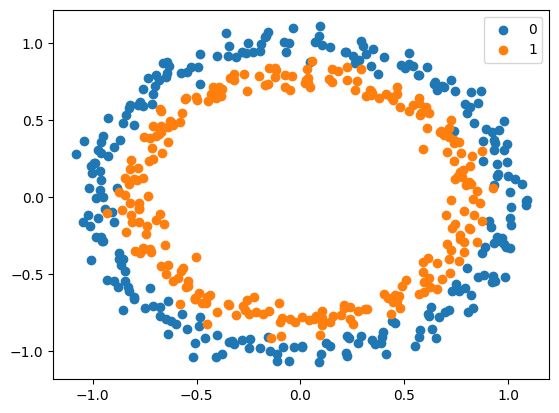

In [ ]:
from sklearn.datasets import make_circles

X, y = make_circles(n_samples = 500, noise = 0.05)

plt.scatter(X[y == 0, 0], X[y == 0, 1], label="0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="1")
plt.legend()
plt.show()

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Normalizamos solo X
x_mean, x_std = X.mean(), X.std()
X_norm = (X - x_mean) / x_std

tensor_X = torch.tensor(X_norm, dtype=torch.float32)
tensor_y = torch.tensor(y, dtype=torch.float32)

my_dataset_circles = TensorDataset(tensor_X,tensor_y)
my_dataloader_circles = DataLoader(my_dataset_circles)

In [ ]:
class MLP_2(torch.nn.Module):
    def __init__(self, num_features):
        super().__init__()

        self.all_layers = torch.nn.Sequential(

            # 1st hidden layer
            torch.nn.Linear(num_features, 25),
            torch.nn.Tanh(),

            # 2nd hidden layer
            torch.nn.Linear(25, 10),
            torch.nn.ReLU(),

            # output layer
            torch.nn.Linear(10, 1)

        )

    def forward(self, x):
        output = self.all_layers(x)
        return output.flatten()

In [ ]:
from torcheval.metrics import BinaryAccuracy, BinaryConfusionMatrix

torch.manual_seed(1)

model_circles = MLP_2(num_features=2)

loss_fn_circles = torch.nn.BCEWithLogitsLoss()

optimizer_circles = torch.optim.Adam(model_circles.parameters(), lr=0.001)

acc_circles = BinaryAccuracy()
m_confusion_circles = BinaryConfusionMatrix(threshold=0.5)

In [ ]:
num_epochs_circles = 100

loss_list_circles, acc_list_circles = [], []

for epoch in range(num_epochs_circles):

    model_circles.train()
    for batch_idx, (features, targets) in enumerate(my_dataloader_circles):

        # forward
        output = model_circles(features)
        loss = loss_fn_circles(output, targets)

        # backward
        optimizer_circles.zero_grad()
        loss.backward()
        optimizer_circles.step()

        acc_circles.update(output, targets)

        loss_list_circles.append(loss.item())
        acc_list_circles.append(acc_circles.compute().item())

        if not batch_idx % 100:
            print(
                f"Epoch: {epoch+1:03d}/{num_epochs_circles:03d}"
                f" | Batch {batch_idx:03d}/{len(my_dataloader_circles):03d}"
                f" | Train Loss: {loss:.2f}"
                f" | Accuracy: {acc_circles.compute():.2f}"
            )

Epoch: 001/100 | Batch 000/500 | Train Loss: 0.84 | Accuracy: 0.00
Epoch: 001/100 | Batch 100/500 | Train Loss: 0.67 | Accuracy: 0.53
Epoch: 001/100 | Batch 200/500 | Train Loss: 0.60 | Accuracy: 0.50
Epoch: 001/100 | Batch 300/500 | Train Loss: 0.71 | Accuracy: 0.49
Epoch: 001/100 | Batch 400/500 | Train Loss: 0.71 | Accuracy: 0.50
Epoch: 002/100 | Batch 000/500 | Train Loss: 0.72 | Accuracy: 0.50
Epoch: 002/100 | Batch 100/500 | Train Loss: 0.70 | Accuracy: 0.51
Epoch: 002/100 | Batch 200/500 | Train Loss: 0.62 | Accuracy: 0.50
Epoch: 002/100 | Batch 300/500 | Train Loss: 0.67 | Accuracy: 0.50
Epoch: 002/100 | Batch 400/500 | Train Loss: 0.68 | Accuracy: 0.50
Epoch: 003/100 | Batch 000/500 | Train Loss: 0.69 | Accuracy: 0.50
Epoch: 003/100 | Batch 100/500 | Train Loss: 0.72 | Accuracy: 0.50
Epoch: 003/100 | Batch 200/500 | Train Loss: 0.62 | Accuracy: 0.50
Epoch: 003/100 | Batch 300/500 | Train Loss: 0.64 | Accuracy: 0.50
Epoch: 003/100 | Batch 400/500 | Train Loss: 0.65 | Accuracy: 

In [ ]:
model_circles.eval()
yp_circles = model_circles(tensor_X)
yp_circles

tensor([  6.1710,  -6.0949,   7.7850,  14.6597,  -4.5005,   5.4907,   7.7929,
          3.1791,  -6.0534,  12.4839,   3.5502,   4.3960,   2.2147,  -3.9655,
        -11.7183, -13.8489,  -7.0861,  -9.6586,  -0.7599,  -7.5668,  -7.1549,
         13.4898,   5.1520,  -7.1021,  -5.8306,  -8.9632,  -0.1021,  -6.0029,
         -9.1627,  -2.0475,   5.1872,   3.7464,   2.0097,   6.1457,  -8.6357,
        -12.8508,  -8.0260,  -0.8288,   4.5277,   2.7064,  -4.0069,   7.0141,
          5.0206,   3.5257,  -1.6852,   9.6961,   8.3531,   3.4426,  -7.9080,
          6.8399,  -9.5273, -11.8625,  -5.7742,   5.4372,  -6.0214,   7.9238,
          7.5302,  -2.9817,  -6.4967,  -6.2139,  -5.1245,  -9.4807,  -9.9107,
          6.0808,   4.2407, -10.5684,  10.3388,   7.0469, -14.5932,  -9.5587,
         -7.0078,   5.0750,   0.3170,   4.7643,   4.6928,  -9.9137, -10.0145,
        -11.7897,  -1.6764,  -7.6320,  -7.8642,   8.0659,  -7.5719,  15.2765,
         -5.0344,  -2.8515,   4.9259,  -3.1665,  -4.0466,   4.78

In [ ]:
k_circles = BinaryConfusionMatrix(threshold=0.)
k_circles.update(yp_circles, tensor_y.long())
print(k_circles.compute())

tensor([[247.,   3.],
        [ 10., 240.]])


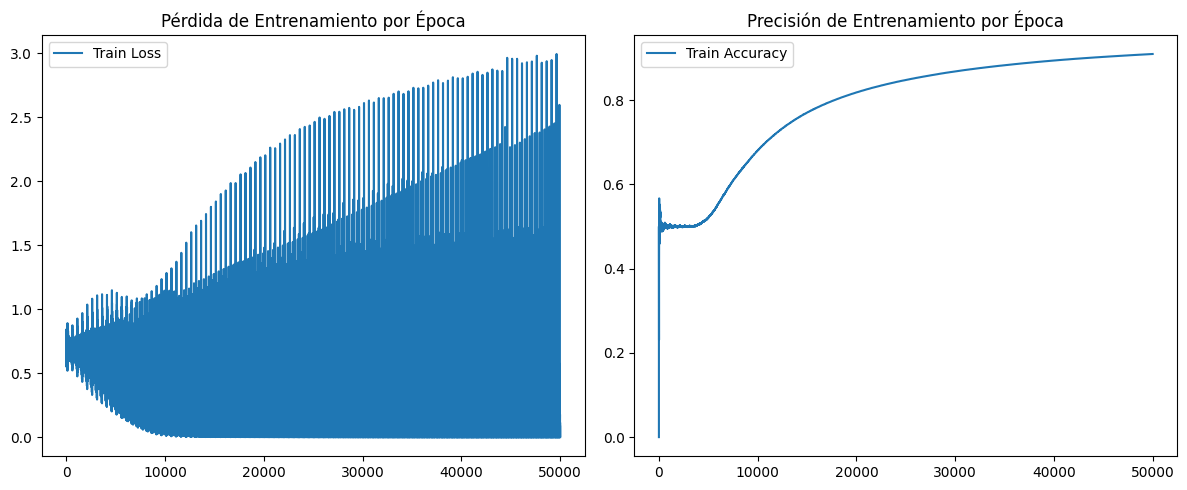

In [ ]:
from matplotlib import pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # Primer subplot para la pérdida
plt.plot(loss_list_circles, label='Train Loss')
plt.legend()
plt.title('Pérdida de Entrenamiento por Época')

plt.subplot(1, 2, 2) # Segundo subplot para la precisión
plt.plot(acc_list_circles, label='Train Accuracy')
plt.legend()
plt.title('Precisión de Entrenamiento por Época')

plt.tight_layout() # Ajustar el diseño para evitar superposiciones
plt.show()

### 03. Ejercicio 3

Haz lo mismo usando make_moons

```python
from sklearn.datasets import make_moons
```

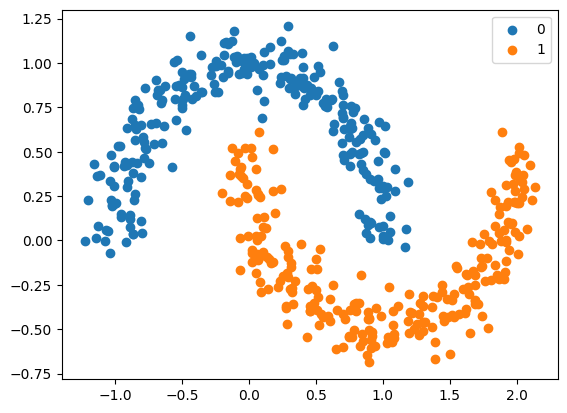

In [ ]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples = 500, noise = 0.1)

plt.scatter(X[y == 0, 0], X[y == 0, 1], label="0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="1")
plt.legend()
plt.show()

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Normalizamos solo X
x_mean, x_std = X.mean(), X.std()
X_norm = (X - x_mean) / x_std

tensor_X = torch.tensor(X_norm, dtype=torch.float32)
tensor_y = torch.tensor(y, dtype=torch.float32)

my_dataset_moons = TensorDataset(tensor_X,tensor_y)
my_dataloader_moons = DataLoader(my_dataset_moons)

In [ ]:
class MLP_3(torch.nn.Module):
    def __init__(self, num_features):
        super().__init__()

        self.all_layers = torch.nn.Sequential(

            # 1st hidden layer
            torch.nn.Linear(num_features, 5),
            torch.nn.Tanh(),

            # 2nd hidden layer
            torch.nn.Linear(5, 5),
            torch.nn.ReLU(),

            # output layer
            torch.nn.Linear(5, 1)

        )

    def forward(self, x):
        output = self.all_layers(x)
        return output.flatten()

In [ ]:
from torcheval.metrics import BinaryAccuracy, BinaryConfusionMatrix

torch.manual_seed(1)

model_moons = MLP_3(num_features=2)

loss_fn_moons = torch.nn.BCEWithLogitsLoss()

optimizer_moons = torch.optim.Adam(model_moons.parameters(), lr=0.0005)

acc_moons = BinaryAccuracy()
m_confusion_moons = BinaryConfusionMatrix(threshold=0.5)

In [ ]:
num_epochs_moons = 100

loss_list_moons, acc_list_moons = [], []

for epoch in range(num_epochs_moons):

    model_moons.train()
    for batch_idx, (features, targets) in enumerate(my_dataloader_moons):

        # forward
        output = model_moons(features)
        loss = loss_fn_moons(output, targets)

        # backward
        optimizer_moons.zero_grad()
        loss.backward()
        optimizer_moons.step()

        acc_moons.update(output, targets)

        loss_list_moons.append(loss.item())
        acc_list_moons.append(acc_moons.compute().item())

        if not batch_idx % 100:
            print(
                f"Epoch: {epoch+1:03d}/{num_epochs_moons:03d}"
                f" | Batch {batch_idx:03d}/{len(my_dataloader_moons):03d}"
                f" | Train Loss: {loss:.2f}"
                f" | Accuracy: {acc_moons.compute():.2f}"
            )

Epoch: 001/100 | Batch 000/500 | Train Loss: 0.56 | Accuracy: 1.00
Epoch: 001/100 | Batch 100/500 | Train Loss: 0.54 | Accuracy: 0.45
Epoch: 001/100 | Batch 200/500 | Train Loss: 0.79 | Accuracy: 0.45
Epoch: 001/100 | Batch 300/500 | Train Loss: 0.77 | Accuracy: 0.49
Epoch: 001/100 | Batch 400/500 | Train Loss: 0.72 | Accuracy: 0.50
Epoch: 002/100 | Batch 000/500 | Train Loss: 0.34 | Accuracy: 0.50
Epoch: 002/100 | Batch 100/500 | Train Loss: 0.31 | Accuracy: 0.49
Epoch: 002/100 | Batch 200/500 | Train Loss: 0.45 | Accuracy: 0.49
Epoch: 002/100 | Batch 300/500 | Train Loss: 0.45 | Accuracy: 0.52
Epoch: 002/100 | Batch 400/500 | Train Loss: 0.38 | Accuracy: 0.56
Epoch: 003/100 | Batch 000/500 | Train Loss: 0.16 | Accuracy: 0.58
Epoch: 003/100 | Batch 100/500 | Train Loss: 0.15 | Accuracy: 0.61
Epoch: 003/100 | Batch 200/500 | Train Loss: 0.19 | Accuracy: 0.63
Epoch: 003/100 | Batch 300/500 | Train Loss: 0.23 | Accuracy: 0.64
Epoch: 003/100 | Batch 400/500 | Train Loss: 0.18 | Accuracy: 

In [ ]:
model_moons.eval()
yp_moons = model_moons(tensor_X)
yp_moons

tensor([ -4.6565,   3.7558,   2.3947,   7.2326,  -5.3464,   4.1368,  -3.9528,
         -4.2216,   2.5001,   4.1731,   5.9825,   4.4596,  -3.7635,  -6.7182,
         -4.5397,   5.2223,   5.7659,  -4.3054,  -6.3651,  -4.0077,   2.3770,
          3.4925,  -3.5264,  -1.2582,   3.8048,   4.5096,   5.1376,   4.5259,
          4.4975,   5.5815,  -2.8727,   5.7179,   3.8851,  -2.9396,   6.3621,
         -6.1895,  -8.4008,  -8.7410,   6.3351,   3.3030,   5.0777,  -7.7132,
          4.1419,   5.2405,  -8.8292,   4.4444,  -2.4537,  -4.0548,   5.4625,
         -4.0961,  -3.3510,   3.7025,  -4.5404,   3.5029,  -3.6336,  -1.7826,
         -4.3538,  -4.0293,   4.3855,   4.4387,   4.2658,  -7.1579,   4.7299,
          4.4780,   5.2472,   5.5651,  -2.9943,  -4.9531,   3.6313,  -3.2237,
         -4.8928,   0.4462,   5.0420,  -6.0640,   3.2339,   5.4071,  -9.0309,
          6.3420,  -7.0093,  -1.8474,   4.5662,  -3.4351,  -3.5159,  -4.0758,
          2.2661,   5.4757,   5.9273,  -4.4132,   0.2294,   5.30

In [ ]:
k_moons = BinaryConfusionMatrix(threshold=0.)
k_moons.update(yp_moons, tensor_y.long())
print(k_moons.compute())

tensor([[249.,   1.],
        [  2., 248.]])


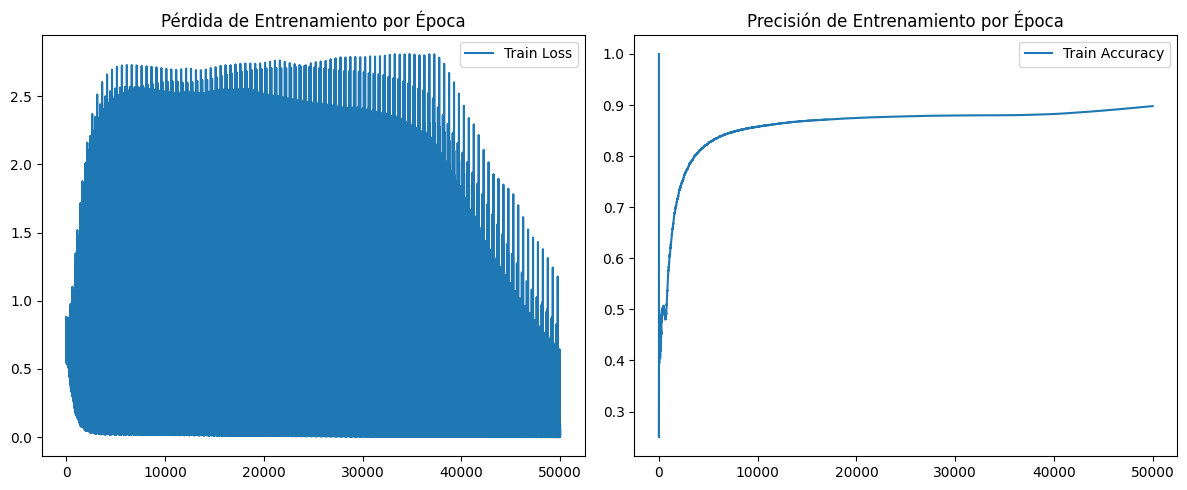

In [ ]:
from matplotlib import pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # Primer subplot para la pérdida
plt.plot(loss_list_moons, label='Train Loss')
plt.legend()
plt.title('Pérdida de Entrenamiento por Época')

plt.subplot(1, 2, 2) # Segundo subplot para la precisión
plt.plot(acc_list_moons, label='Train Accuracy')
plt.legend()
plt.title('Precisión de Entrenamiento por Época')

plt.tight_layout() # Ajustar el diseño para evitar superposiciones
plt.show()

### 04. Ejercicio 04. Clasificación binaria con datos de infidelidad

Se analizan unos datos obtenido de Kaggle.com sobre una encuesta de infidelidad: [enlace](https://www.google.com/url?q=https%3A%2F%2Fwww.kaggle.com%2Fdatasets%2Futkarshx27%2Ffairs-extramarital-affairs-data)

Las variables son:

**Criterio**: affairs.

**Predictoras**: gender, age, yearsmarried, children, religiousness, education, occupation, rating.

La variable criterio es de tipo dicotómico **0 = no, 1 = sí** por lo que el análisis convencional nos lleva a un modelo binomial. La precisión (accuracy) en la clasificación obtenida con este modelo es de 0.72

Construye un MLP que supere la precisión del modelo lineal

In [ ]:
import pandas as pd

url = 'https://raw.githubusercontent.com/mcstllns/UNIR2024/main/data-affairs.csv'
data  = pd.read_csv(url)
print(data.keys())
data.head()


Index(['affairs', 'gender', 'age', 'yearsmarried', 'children', 'religiousness',
       'education', 'occupation', 'rating'],
      dtype='object')


,affairs,gender,age,yearsmarried,children,religiousness,education,occupation,rating
0,0,0,37.0,10.00,0,3,18,7,4
1,0,1,27.0,4.00,0,4,14,6,4
2,0,1,32.0,15.00,1,1,12,1,4
3,0,0,57.0,15.00,1,5,18,6,5
4,0,0,22.0,0.75,0,2,17,6,3


In [ ]:
X = data.drop('affairs', axis=1)
y = data['affairs']

print(X.shape)
print(y.shape)

(601, 8)
(601,)


In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Normalizamos solo X
x_mean, x_std = X.mean(), X.std()
X_norm = (X - x_mean) / x_std

tensor_X = torch.tensor(X_norm.values, dtype=torch.float32)
tensor_y = torch.tensor(y.values, dtype=torch.float32)

# Creamos el dataset y el dataloader con todos los datos
my_dataset_infieles = TensorDataset(tensor_X,tensor_y)

batch_size_infieles = 32 # Definimos un tamaño de lote

my_dataloader_infieles = DataLoader(my_dataset_infieles, batch_size=batch_size_infieles, shuffle=True)

In [ ]:
class MLP_infieles(torch.nn.Module):
    def __init__(self, num_features):
        super().__init__()

        self.all_layers = torch.nn.Sequential(

            # 1st hidden layer
            torch.nn.Linear(num_features, 50),
            torch.nn.ReLU(),

            # 2nd hidden layer
            torch.nn.Linear(50, 50),
            torch.nn.ReLU(),

            # 3rd hidden layer
            torch.nn.Linear(50, 50),
            torch.nn.ReLU(),

            # output layer
            torch.nn.Linear(50, 1)

        )

    def forward(self, x):
        output = self.all_layers(x)
        return output.flatten()

In [ ]:
from torcheval.metrics import BinaryAccuracy, BinaryConfusionMatrix

torch.manual_seed(1)

model_infieles = MLP_infieles(num_features=8)

loss_fn_infieles = torch.nn.BCEWithLogitsLoss()

optimizer_infieles = torch.optim.Adam(model_infieles.parameters(), lr=0.001)

# Métricas para el entrenamiento
acc_infieles = BinaryAccuracy()
m_confusion_infieles = BinaryConfusionMatrix(threshold=0.5)

In [ ]:
num_epochs_infieles = 1000 # Número máximo de épocas

loss_list_infieles, acc_list_infieles = [], []

# Parámetros para Early Stopping (basado en la pérdida de entrenamiento)
patience = 10 # Número de épocas a esperar si no hay mejora
min_delta = 0.001 # Cambio mínimo en la pérdida para considerarse mejora
best_train_loss = float('inf') # Inicializar con un valor muy alto
patience_counter = 0
best_model_state = None # Para guardar el estado del mejor modelo
best_epoch = 0

for epoch in range(num_epochs_infieles):
    model_infieles.train()
    current_train_loss = 0.0
    acc_infieles.reset() # Reiniciar la precisión para la nueva época

    for batch_idx, (features, targets) in enumerate(my_dataloader_infieles):
        # Forward pass
        output = model_infieles(features)
        loss = loss_fn_infieles(output, targets)

        # Backward pass y optimización
        optimizer_infieles.zero_grad()
        loss.backward()
        optimizer_infieles.step()

        current_train_loss += loss.item()
        acc_infieles.update(output, targets)

    # Calcular la pérdida y precisión promedio por época
    avg_train_loss = current_train_loss / len(my_dataloader_infieles)
    epoch_train_acc = acc_infieles.compute().item()
    loss_list_infieles.append(avg_train_loss)
    acc_list_infieles.append(epoch_train_acc)

    print(
        f"Epoch: {epoch+1:03d}/{num_epochs_infieles:03d}"
        f" | Train Loss: {avg_train_loss:.2f}"
        f" | Train Accuracy: {epoch_train_acc:.2f}"
    )

    # Comprobación de Early Stopping
    if avg_train_loss < best_train_loss - min_delta:
        best_train_loss = avg_train_loss
        best_model_state = model_infieles.state_dict() # Guardar el estado del mejor modelo
        patience_counter = 0 # Resetear el contador de paciencia
        best_epoch = epoch + 1
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping en la época {epoch+1}. No hubo mejora en la pérdida de entrenamiento por {patience} épocas.")
            break

# Cargar el estado del mejor modelo si hubo early stopping
if best_model_state:
    model_infieles.load_state_dict(best_model_state)
    print(f"Se cargó el modelo de la época {best_epoch} con la mejor pérdida de entrenamiento: {best_train_loss:.2f}")

Epoch: 001/1000 | Train Loss: 0.65 | Train Accuracy: 0.75
Epoch: 002/1000 | Train Loss: 0.58 | Train Accuracy: 0.75
Epoch: 003/1000 | Train Loss: 0.54 | Train Accuracy: 0.75
Epoch: 004/1000 | Train Loss: 0.52 | Train Accuracy: 0.75
Epoch: 005/1000 | Train Loss: 0.52 | Train Accuracy: 0.75
Epoch: 006/1000 | Train Loss: 0.51 | Train Accuracy: 0.75
Epoch: 007/1000 | Train Loss: 0.51 | Train Accuracy: 0.75
Epoch: 008/1000 | Train Loss: 0.50 | Train Accuracy: 0.75
Epoch: 009/1000 | Train Loss: 0.50 | Train Accuracy: 0.75
Epoch: 010/1000 | Train Loss: 0.50 | Train Accuracy: 0.75
Epoch: 011/1000 | Train Loss: 0.49 | Train Accuracy: 0.75
Epoch: 012/1000 | Train Loss: 0.49 | Train Accuracy: 0.75
Epoch: 013/1000 | Train Loss: 0.49 | Train Accuracy: 0.75
Epoch: 014/1000 | Train Loss: 0.48 | Train Accuracy: 0.75
Epoch: 015/1000 | Train Loss: 0.48 | Train Accuracy: 0.76
Epoch: 016/1000 | Train Loss: 0.48 | Train Accuracy: 0.75
Epoch: 017/1000 | Train Loss: 0.47 | Train Accuracy: 0.76
Epoch: 018/100

In [ ]:
model_infieles.eval()
yp_infieles = model_infieles(tensor_X)
yp_infieles

tensor([ -3.9241, -10.2528,  -7.3891, -12.5247,  -8.1703,   1.2694,  -8.0937,
        -18.0937,  -2.0568,  -2.4142,  -3.0104,  -0.7764,  -3.4376,  -9.4668,
         -4.5297,  -1.9026,  -2.8857, -11.3430,  -7.0048, -10.1980,  -7.0048,
         -7.0048,  -2.7777,  -5.8146,  -9.2789,  -5.0323, -12.3634,  -5.1936,
         -4.1742,  -1.4718,  -4.3765,  -6.8727,  -4.8961,  -4.9074,  -2.8455,
        -11.0572, -10.3121,  -7.9463,  -7.1318, -17.3335,  -0.8051,  -6.9929,
        -13.9750,  -1.8634,  -9.6973,  -5.5660,  -7.9080,  -1.5242,  -4.8972,
         -2.8396,  -5.4030,  -7.8011,  -2.2290,  -1.4266,  -1.8819,  -2.0123,
         -8.3924,  -3.5859, -10.7299,  -2.4867,  -5.8800,  -5.2960,  -8.0135,
         -3.9861,  -2.8815,  -3.2351,  -2.7759, -10.3838,  -8.8625,  -5.8597,
         -0.1712,  -4.1423,  -5.5198,  -7.2019, -19.1335,  -4.6946, -12.4142,
         -1.9788,  -6.8727, -16.3147,  -2.9392, -13.5137,  -3.2559,  -8.0510,
        -16.2351,  -5.2962,  -2.6171, -10.6762,  -8.2696,  -6.27

In [ ]:
k_infieles = BinaryConfusionMatrix(threshold=0.)
k_infieles.update(yp_infieles, tensor_y.long())
print(k_infieles.compute())

tensor([[445.,   6.],
        [ 10., 140.]])


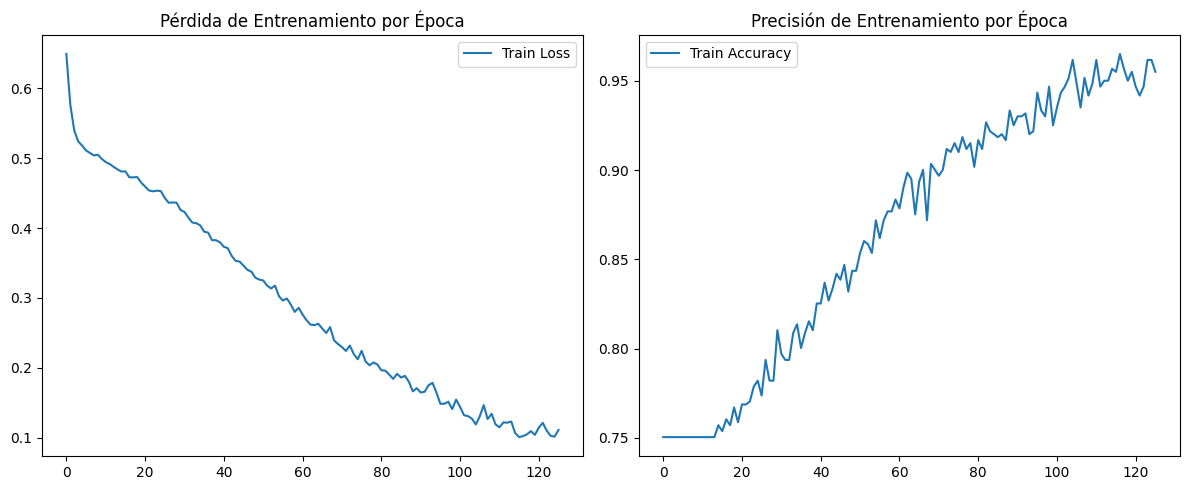

In [ ]:
from matplotlib import pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # Primer subplot para la pérdida
plt.plot(loss_list_infieles, label='Train Loss')
plt.legend()
plt.title('Pérdida de Entrenamiento por Época')

plt.subplot(1, 2, 2) # Segundo subplot para la precisión
plt.plot(acc_list_infieles, label='Train Accuracy')
plt.legend()
plt.title('Precisión de Entrenamiento por Época')

plt.tight_layout() # Ajustar el diseño para evitar superposiciones
plt.show()